Aquí tienes el código completo con las mejoras que atacan directamente los dos problemas que identificaste:
Invarianza de escala: Ahora la red se inicializa con los valores base extraídos de la imagen (no con -0.5 genérico), y se añade una regularización suave que penaliza que los módulos se alejen de esa inicialización física razonable. Esto rompe la degeneración de escala de forma robusta.
Capacidad insuficiente para 7 fases: Se aumenta la arquitectura a [1, 128, 128, 128, 1], los puntos de colocación a 4000, las épocas a 10000, y el perfilado de k es más suave (5 → 80 en lugar de 10 → 120) para evitar inestabilidades con muchas interfaces.

=== CONFIGURACIÓN SHM MULTI-FASE (Publicación) ===


1. Usar imagen Sintética
2. Cargar imagen Real
Elige (1 o 2):  2
Introduce el número de fases (ej. 4):  7
Fase de referencia SANA que no sufrirá daño (1 a 7, default 1):  1
Fases a dañar separadas por coma (ej. 2,3):  2
Factores de severidad respectivos (ej. 0.5,0.8):  0.5
Dirección de la línea de extracción (v = vertical, h = horizontal):  v
Posición de la línea (0.0 a 1.0, ej 0.5):  0.55
Nivel de ruido en N(y) (ej. 0.02):  



--- PASO 1: PREPARANDO IMÁGENES ---


Ruta de la imagen real:  benign.png



--- Procesando: ESTADO SANO ---


Entrenando PINN (ESTADO SANO):   0%|                  | 0/10000 [00:00<?, ?it/s]/home/amaury/.local/lib/python3.10/site-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Entrenando PINN (ESTADO SANO): 100%|█| 10000/10000 [05:36<00:00, 29.69it/s, Loss



--- Procesando: ESTADO DAÑADO ---


Entrenando PINN (ESTADO DAÑADO): 100%|█| 10000/10000 [06:11<00:00, 26.92it/s, Lo




 TABLA 1: RECONSTRUCCIÓN ESTADO SANO 
Fase<< | E Original (Base)< | E Estimado (PINN)< | Error %<
--------------------------------------------------
1      | 66.17              | 66.17              | 0.00    %
2      | 32.22              | 32.77              | 1.70    %
3      | 92.47              | 91.18              | 1.40    %
4      | 69.03              | 67.82              | 1.75    %
5      | 49.04              | 49.39              | 0.72    %
6      | 35.72              | 35.52              | 0.56    %
7      | 18.35              | 18.87              | 2.83    %

 TABLA 2: RECONSTRUCCIÓN ESTADO DEFECTUOSO 
Fase<< | E Original (Base)< | E Estimado (PINN)< | Error %<
--------------------------------------------------
1      | 66.08              | 66.17              | 0.13    %
2      | 25.15              | 26.78              | 6.48    %
3      | 91.71              | 86.59              | 5.58    %
4      | 69.03              | 66.97              | 2.97    %
5      | 49.04        

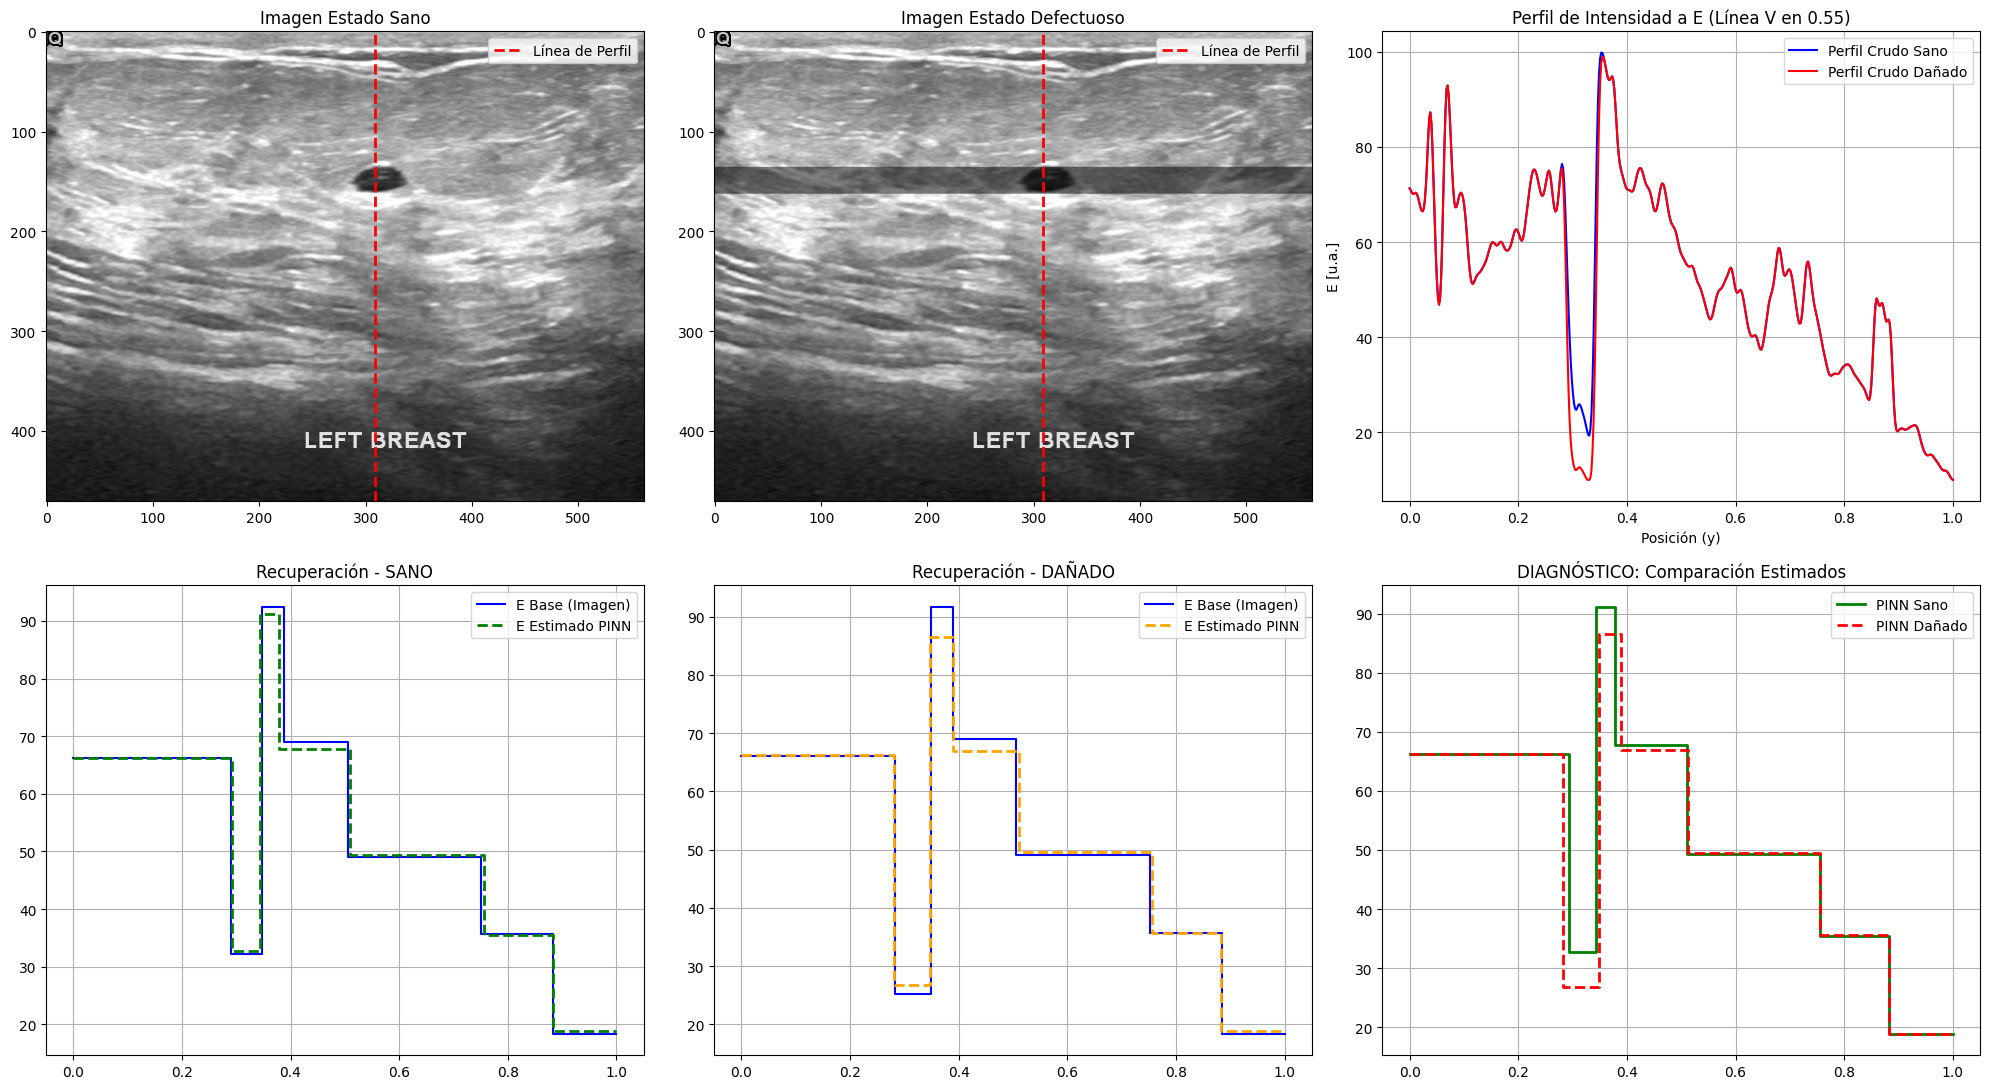

[INFO] Figuras de publicación guardadas en 'figures_paper/' (PNG).

--- CÓDIGO LATEX DE LAS TABLAS ---
% ======= TABLA 1: RECONSTRUCCIÓN ESTADO SANO =======
\begin{table}[h]
\centering
\caption{Recuperación de módulos para el laminado sano.}
\label{tab:sano}
\begin{tabular}{cccc}
\toprule
Fase & $E_{\text{base}}$ [u.a.] & $E_{\text{PINN}}$ [u.a.] & Error \% \\
\midrule
1 & 66.17 & 66.17 & 0.00 \\
2 & 32.22 & 32.77 & 1.70 \\
3 & 92.47 & 91.18 & 1.40 \\
4 & 69.03 & 67.82 & 1.75 \\
5 & 49.04 & 49.39 & 0.72 \\
6 & 35.72 & 35.52 & 0.56 \\
7 & 18.35 & 18.87 & 2.83 \\
\bottomrule
\end{tabular}
\end{table}

% ======= TABLA 2: RECONSTRUCCIÓN ESTADO DAÑADO =======
\begin{table}[h]
\centering
\caption{Recuperación de módulos para el laminado dañado.}
\label{tab:danado}
\begin{tabular}{cccc}
\toprule
Fase & $E_{\text{base}}$ [u.a.] & $E_{\text{PINN}}$ [u.a.] & Error \% \\
\midrule
1 & 66.08 & 66.17 & 0.13 \\
2 & 25.15 & 26.78 & 6.48 \\
3 & 91.71 & 86.59 & 5.58 \\
4 & 69.03 & 66.97 & 2.97 \\
5 & 49

In [1]:
# =============================================================================
# HERRAMIENTA SHM: DIAGNÓSTICO ESTRUCTURAL MEJORADO
# + CONFIGURACIÓN CENTRALIZADA Y SALIDAS PARA PUBLICACIÓN (PNG + LATEX)
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from PIL import Image

import torch
import torch.nn as nn
from tqdm import trange

# =============================================================================
# IMPORTACIÓN DEL OPTIMIZADOR SOAP (CON FALLBACK)
# =============================================================================
try:
    from soap import SOAP
    HAS_SOAP = True
except ImportError:
    HAS_SOAP = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32

# =============================================================================
# 0. CONFIGURACIÓN CENTRAL (DICCIONARIO)
# =============================================================================
CONFIG = {
    # Imagen sintética
    'width': 400,
    'noise_level_img': 5,

    # Extracción de perfil
    'line_frac': 0.5,
    'line_dir': 'v',
    'num_points': 500,
    'smooth_sigma': 2,
    'E_range': (10.0, 100.0),          # (E_min, E_max) para mapeo

    # Discretización
    'n_phases': 4,
    'smooth_window': 15,

    # PINN – arquitectura (aumentada para soportar más fases)
    'LAYERS': [1, 128, 128, 128, 1],
    'ACTIVATION': nn.Tanh,

    # PINN – entrenamiento
    'LR_NET': 1e-3,
    'LR_VF': 5e-4,
    'LR_C': 1e-3,          # más conservador para estabilidad con 7 fases
    'EPOCHS': 10000,
    'N_COLLOC_PTS': 4000,
    'W_PDE': 0.1,
    'W_INT': 100.0,
    'W_DATA': 500.0,
    'W_REG_C': 0.05,       # regularización suave sobre C (rompe invarianza escala)
    'K_SHARP_INIT': 5.0,
    'K_SHARP_FINAL': 80.0,
    'SEED': 1234,

    # Ruido para los datos de desplazamiento
    'noise_level_data': 0.02,

    # Fase de referencia (anclaje)
    'anchor_idx': 0
}

# =============================================================================
# 1. GENERADORES Y MANEJO DE IMÁGENES
# =============================================================================
def generate_laminate_image(n_phases, phase_thicknesses, phase_moduli,
                            width=None, noise_level=None, defect_dict=None):
    width = width if width is not None else CONFIG['width']
    noise_level = noise_level if noise_level is not None else CONFIG['noise_level_img']
    total_height = int(600 * sum(phase_thicknesses))
    heights = [int(h * total_height) for h in phase_thicknesses]
    heights[-1] = total_height - sum(heights[:-1])
    
    real_moduli = phase_moduli.copy()
    if defect_dict:
        for phase_idx, factor in defect_dict.items():
            if 0 <= phase_idx < n_phases:
                real_moduli[phase_idx] *= factor
    
    img = np.zeros((total_height, width))
    row_start = 0
    for i in range(n_phases):
        row_end = row_start + heights[i]
        img[row_start:row_end, :] = real_moduli[i]
        row_start = row_end
    
    mod_min, mod_max = min(phase_moduli), max(phase_moduli)
    mod_range = mod_max - mod_min
    img_gray = 30 + (img - mod_min) / mod_range * 195  
    img_gray += np.random.normal(0, noise_level, img_gray.shape)
    img_gray = np.clip(img_gray, 0, 255).astype(np.uint8)
    
    return img_gray, real_moduli

def load_real_image(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"No se encontró: {filepath}")
    return np.array(Image.open(filepath).convert('L'))

def create_damaged_image(img_healthy, lam_healthy, defect_dict):
    img_def = img_healthy.copy().astype(np.float32)
    h = img_healthy.shape[0]
    for phase_idx, factor in defect_dict.items():
        if 0 <= phase_idx < lam_healthy['n_phases']:
            y_start = lam_healthy['interfaces'][phase_idx]
            y_end = lam_healthy['interfaces'][phase_idx+1] if (phase_idx+1) < lam_healthy['n_phases'] else 1.0
            row_start, row_end = int(y_start * h), int(y_end * h)
            img_def[row_start:row_end, :] *= factor
    return np.clip(img_def, 0, 255).astype(np.uint8)

# =============================================================================
# 2. EXTRACCIÓN DE PERFILES CON CALIBRACIÓN FIJA
# =============================================================================
def extract_profile_from_image(img, line_frac=None, direction=None,
                               num_points=None, smooth_sigma=None,
                               ref_min=None, ref_max=None):
    line_frac = line_frac if line_frac is not None else CONFIG['line_frac']
    direction = direction if direction is not None else CONFIG['line_dir']
    num_points = num_points if num_points is not None else CONFIG['num_points']
    smooth_sigma = smooth_sigma if smooth_sigma is not None else CONFIG['smooth_sigma']
    h, w = img.shape
    if direction.lower() == 'v':
        center = int(line_frac * w)
        half_window = max(1, w // 40)
        profile = np.mean(img[:, max(0, center-half_window):min(w, center+half_window)], axis=1)
        y = np.linspace(0, 1, h)
    else:  
        center = int(line_frac * h)
        half_window = max(1, h // 40)
        profile = np.mean(img[max(0, center-half_window):min(h, center+half_window), :], axis=0)
        y = np.linspace(0, 1, w)
    
    profile_smooth = gaussian_filter1d(profile, sigma=smooth_sigma)
    
    pmin = profile_smooth.min() if ref_min is None else ref_min
    pmax = profile_smooth.max() if ref_max is None else ref_max
    if pmax == pmin: pmax = pmin + 1e-6
    
    profile_norm = (profile_smooth - pmin) / (pmax - pmin)
    profile_norm = np.clip(profile_norm, 0, 1)
    
    E_min, E_max = CONFIG['E_range']
    E_profile = E_min + (E_max - E_min) * profile_norm
    y_grid = np.linspace(0, 1, num_points)
    E_interp = np.interp(y_grid, y, E_profile)
    return y_grid, E_interp, pmin, pmax

def discretize_profile_to_laminate(y, E, n_phases=None, smooth_window=None):
    n_phases = n_phases if n_phases is not None else CONFIG['n_phases']
    smooth_window = smooth_window if smooth_window is not None else CONFIG['smooth_window']
    window = np.ones(smooth_window) / smooth_window
    E_smooth = np.convolve(E, window, mode='same')
    N_points = len(y)
    left, right = np.arange(N_points, dtype=int), np.arange(1, N_points+1, dtype=int)
    n_seg = N_points
    
    while n_seg > n_phases:
        best_cost, best_k = np.inf, -1
        for k in range(n_seg - 1):
            seg_values = E_smooth[left[k]:right[k+1]]
            cost_increase = np.sum((seg_values - np.mean(seg_values))**2) - \
                            (np.sum((E_smooth[left[k]:right[k]] - np.mean(E_smooth[left[k]:right[k]]))**2) + \
                             np.sum((E_smooth[left[k+1]:right[k+1]] - np.mean(E_smooth[left[k+1]:right[k+1]]))**2))
            if cost_increase < best_cost: best_cost, best_k = cost_increase, k
        left, right = np.delete(left, best_k+1), np.delete(right, best_k)
        n_seg -= 1

    interfaces, moduli, volume_fractions = [], [], []
    for i in range(n_phases):
        interfaces.append(y[left[i]])
        moduli.append(np.mean(E[left[i]:right[i]]))
        volume_fractions.append((y[right[i]-1] - y[left[i]]) / (y[-1] - y[0]))
        
    return {'n_phases': n_phases, 'interfaces': interfaces, 'moduli': moduli, 'volume_fractions': volume_fractions}

def solve_cell_problem_from_laminate(lam_data, N_points=500):
    E, interfaces, V = lam_data['moduli'], lam_data['interfaces'][1:], lam_data['volume_fractions']
    n = len(E)
    denom = sum(V[i] / E[i] for i in range(n))
    q = 1.0 / denom if denom != 0 else 1.0
    yi = np.concatenate(([0.0], interfaces, [1.0]))
    y_grid, N = np.linspace(0, 1, N_points), np.zeros(N_points)
    N_left = 0.0   

    for i in range(n):
        y_start, y_end = yi[i], yi[i+1]
        idx = (y_grid >= y_start) & (y_grid < y_end) if i < n-1 else (y_grid >= y_start) & (y_grid <= y_end)
        dN_dy = q / E[i] - 1.0
        N[idx] = N_left + dN_dy * (y_grid[idx] - y_start)
        N_left += dN_dy * (y_end - y_start)

    return y_grid, N

# =============================================================================
# 3. RED NEURONAL PINN
# =============================================================================
def get_pinn_config(max_modulus, anchor_val):
    """Devuelve un sub‑diccionario con la configuración de la PINN."""
    return {
        'LAYERS': CONFIG['LAYERS'],
        'ACTIVATION': CONFIG['ACTIVATION'],
        'LR_NET': CONFIG['LR_NET'],
        'LR_VF': CONFIG['LR_VF'],
        'LR_C': CONFIG['LR_C'],
        'EPOCHS': CONFIG['EPOCHS'],
        'N_COLLOC_PTS': CONFIG['N_COLLOC_PTS'],
        'W_PDE': CONFIG['W_PDE'],
        'W_INT': CONFIG['W_INT'],
        'W_DATA': CONFIG['W_DATA'],
        'W_REG_C': CONFIG['W_REG_C'],
        'MODULI_SCALE': max_modulus,
        'E_ANCHOR': anchor_val,
        'ANCHOR_IDX': CONFIG['anchor_idx'],
        'K_SHARP_INIT': CONFIG['K_SHARP_INIT'],
        'K_SHARP_FINAL': CONFIG['K_SHARP_FINAL'],
        'SEED': CONFIG['SEED']
    }

class MultiPhasePINN(nn.Module):
    def __init__(self, cfg, y_data, N_data, n_phases, init_moduli=None):
        super().__init__()
        self.cfg, self.n = cfg, n_phases
        self.y_data = torch.tensor(y_data, device=DEVICE, dtype=DTYPE).view(-1, 1)
        self.N_data = torch.tensor(N_data, device=DEVICE, dtype=DTYPE).view(-1, 1)
        self.vf_logits = nn.Parameter(torch.ones(self.n, device=DEVICE) * 0.5)
        
        # ---------------------------------------------------------------------
        # INICIALIZACIÓN INFORMADA DE MÓDULOS (rompe invarianza de escala)
        # Si se proporcionan valores base de la imagen, se inicializa C_param
        # desde el logaritmo de esos valores. Esto ancla la escala global
        # de forma física y evita que el optimizador vague en el espacio kE.
        # ---------------------------------------------------------------------
        if init_moduli is not None:
            init_C = np.log(np.array(init_moduli, dtype=np.float32) / cfg['MODULI_SCALE'])
            self.C_param = nn.Parameter(torch.tensor(init_C, device=DEVICE, dtype=DTYPE))
        else:
            self.C_param = nn.Parameter(torch.ones(self.n, device=DEVICE) * -0.5)
        
        # Guardar inicialización para regularización suave (prior físico)
        self.C_param_init = self.C_param.detach().clone()
        
        self.nets = nn.ModuleList([nn.Sequential(
            nn.Linear(1, cfg['LAYERS'][1]), cfg['ACTIVATION'](),
            nn.Linear(cfg['LAYERS'][1], cfg['LAYERS'][2]), cfg['ACTIVATION'](),
            nn.Linear(cfg['LAYERS'][2], 1)) for _ in range(self.n)])
        self.to(DEVICE)

    @property
    def vf(self): return torch.softmax(self.vf_logits, dim=0)
    @property
    def interfaces(self): return torch.cumsum(self.vf[:-1], dim=0)
    @property
    def C(self): 
        c_vals = torch.exp(self.C_param) * self.cfg['MODULI_SCALE']
        idx = self.cfg['ANCHOR_IDX']
        anchor = torch.tensor([self.cfg['E_ANCHOR']], device=DEVICE, dtype=DTYPE)
        return torch.cat([c_vals[:idx], anchor, c_vals[idx+1:]])

    def soft_membership(self, y, k):
        L = torch.cat([torch.tensor([0.0], device=DEVICE), self.interfaces, torch.tensor([1.0], device=DEVICE)])
        p = torch.sigmoid(k * (y.flatten().unsqueeze(0) - L[:-1].unsqueeze(1))) - torch.sigmoid(k * (y.flatten().unsqueeze(0) - L[1:].unsqueeze(1)))
        return p / (p.sum(dim=0, keepdim=True) + 1e-8)

    def train_step(self, k, optimizer):
        optimizer.zero_grad()
        C_curr = self.C / self.cfg['MODULI_SCALE']
        y_col = torch.linspace(0, 1, self.cfg['N_COLLOC_PTS'], device=DEVICE).reshape(-1,1).requires_grad_(True)
        m_col = self.soft_membership(y_col, k)
        
        loss_pde = sum(torch.mean(m_col[i].reshape(-1,1) * (C_curr[i] * torch.autograd.grad(torch.autograd.grad(self.nets[i](y_col), y_col, torch.ones_like(self.nets[i](y_col)), create_graph=True)[0], y_col, torch.ones_like(self.nets[i](y_col)), create_graph=True)[0])**2) for i in range(self.n))
        
        m_dat = self.soft_membership(self.y_data, k)
        loss_data = torch.mean((sum(m_dat[i].reshape(-1,1) * self.nets[i](self.y_data) for i in range(self.n)) - self.N_data)**2)
        
        ints = self.interfaces
        loss_int = 0
        for i in range(self.n-1):
            yi = ints[i].reshape(1,1).requires_grad_(True)
            u_i, u_ip1 = self.nets[i](yi), self.nets[i+1](yi)
            u_iy = torch.autograd.grad(u_i, yi, torch.ones_like(u_i), create_graph=True)[0]
            u_ip1y = torch.autograd.grad(u_ip1, yi, torch.ones_like(u_ip1), create_graph=True)[0]
            loss_int += (u_i - u_ip1)**2 + (C_curr[i]*(1+u_iy) - C_curr[i+1]*(1+u_ip1y))**2

        # Regularización suave sobre C para mantenerlo cerca de la inicialización física
        loss_reg_c = torch.mean((self.C_param - self.C_param_init)**2)
        
        total_loss = (self.cfg['W_DATA']*loss_data + 
                      self.cfg['W_PDE']*loss_pde + 
                      self.cfg['W_INT']*loss_int + 
                      self.cfg['W_REG_C']*loss_reg_c)
        total_loss.backward()
        optimizer.step()
        return total_loss.item()

# =============================================================================
# 4. ORQUESTADOR (ANALIZAR 1 IMAGEN)
# =============================================================================
def analyze_laminate_image(img, n_phases, noise_level, line_frac, line_dir, 
                           anchor_val=None, anchor_idx=0, desc_text="", ref_min=None, ref_max=None):
    print(f"\n--- Procesando: {desc_text} ---")
    y_prof, E_prof, pmin_out, pmax_out = extract_profile_from_image(img, line_frac, line_dir, ref_min=ref_min, ref_max=ref_max)
    lam_def = discretize_profile_to_laminate(y_prof, E_prof, n_phases=n_phases)
    y_N, N_exact = solve_cell_problem_from_laminate(lam_def)
    
    # FIJAR SEMILLA ANTES DE CUALQUIER RUIDO ALEATORIO (reproducibilidad)
    seed = CONFIG['SEED']
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    noise = np.random.normal(0, noise_level * np.max(np.abs(N_exact)), size=N_exact.shape)
    N_obs = N_exact + noise

    anchor = anchor_val if anchor_val is not None else lam_def['moduli'][anchor_idx]
    cfg = get_pinn_config(np.max(lam_def['moduli']) * 1.5, anchor)
    
    # Pasar los módulos base de la imagen como inicialización informada
    model = MultiPhasePINN(cfg, y_N, N_obs, n_phases, init_moduli=lam_def['moduli'])
    param_groups = [{'params': model.nets.parameters(), 'lr': cfg['LR_NET']},
                    {'params': [model.vf_logits], 'lr': cfg['LR_VF']},
                    {'params': [model.C_param], 'lr': cfg['LR_C']}]

    opt = SOAP(param_groups, lr=cfg['LR_NET'], precondition_frequency=10) if HAS_SOAP else torch.optim.Adam(param_groups)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3000, gamma=0.5)

    pbar = trange(cfg['EPOCHS'], desc=f"Entrenando PINN ({desc_text})")
    for e in pbar:
        k = cfg['K_SHARP_INIT'] + (cfg['K_SHARP_FINAL'] - cfg['K_SHARP_INIT']) * (e/cfg['EPOCHS'])
        loss_val = model.train_step(k, opt)
        scheduler.step()
        if e % 1000 == 0: pbar.set_postfix({'Loss': f"{loss_val:.2e}"})

    return {
        'img': img, 'y_prof': y_prof, 'E_prof': E_prof, 'lam_def': lam_def,
        'model': model, 'E_est': model.C.detach().cpu().numpy(),
        'pmin': pmin_out, 'pmax': pmax_out
    }

# =============================================================================
# 5. VISUALIZACIÓN COMPARATIVA (GUARDADO PNG)
# =============================================================================
def plot_comparison_and_save(res_healthy, res_defect, line_dir, line_frac):
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    
    def draw_extraction_line(ax, img_shape):
        if line_dir.lower() == 'v':
            ax.axvline(x=line_frac * img_shape[1], color='red', linestyle='--', linewidth=2, label='Línea de Perfil')
        else:
            ax.axhline(y=line_frac * img_shape[0], color='red', linestyle='--', linewidth=2, label='Línea de Perfil')
        ax.legend()

    # 1. Imágenes
    axes[0,0].imshow(res_healthy['img'], cmap='gray', aspect='auto')
    axes[0,0].set_title('Imagen Estado Sano')
    draw_extraction_line(axes[0,0], res_healthy['img'].shape)

    axes[0,1].imshow(res_defect['img'], cmap='gray', aspect='auto')
    axes[0,1].set_title('Imagen Estado Defectuoso')
    draw_extraction_line(axes[0,1], res_defect['img'].shape)

    # 2. Comparación Perfiles Crudos
    axes[0,2].plot(res_healthy['y_prof'], res_healthy['E_prof'], 'b-', label='Perfil Crudo Sano')
    axes[0,2].plot(res_defect['y_prof'], res_defect['E_prof'], 'r-', label='Perfil Crudo Dañado')
    axes[0,2].set_title(f'Perfil de Intensidad a E (Línea {line_dir.upper()} en {line_frac})')
    axes[0,2].set_xlabel('Posición (y)'); axes[0,2].set_ylabel('E [u.a.]')
    axes[0,2].legend(); axes[0,2].grid(True)

    # 3. SANO: Original vs PINN
    int_h = np.concatenate(([0.0], res_healthy['lam_def']['interfaces'][1:], [1.0]))
    axes[1,0].step(int_h, np.concatenate((res_healthy['lam_def']['moduli'], [res_healthy['lam_def']['moduli'][-1]])), where='post', color='blue', label='E Base (Imagen)')
    axes[1,0].step(np.concatenate(([0.0], res_healthy['model'].interfaces.detach().cpu().numpy(), [1.0])), np.concatenate((res_healthy['E_est'], [res_healthy['E_est'][-1]])), where='post', color='green', linestyle='--', linewidth=2, label='E Estimado PINN')
    axes[1,0].set_title('Recuperación - SANO')
    axes[1,0].legend(); axes[1,0].grid(True)
    
    # 4. DAÑADO: Original vs PINN
    int_d = np.concatenate(([0.0], res_defect['lam_def']['interfaces'][1:], [1.0]))
    axes[1,1].step(int_d, np.concatenate((res_defect['lam_def']['moduli'], [res_defect['lam_def']['moduli'][-1]])), where='post', color='blue', label='E Base (Imagen)')
    axes[1,1].step(np.concatenate(([0.0], res_defect['model'].interfaces.detach().cpu().numpy(), [1.0])), np.concatenate((res_defect['E_est'], [res_defect['E_est'][-1]])), where='post', color='orange', linestyle='--', linewidth=2, label='E Estimado PINN')
    axes[1,1].set_title('Recuperación - DAÑADO')
    axes[1,1].legend(); axes[1,1].grid(True)
    
    # 5. DETECCIÓN: PINN Sano vs PINN Dañado
    axes[1,2].step(np.concatenate(([0.0], res_healthy['model'].interfaces.detach().cpu().numpy(), [1.0])), np.concatenate((res_healthy['E_est'], [res_healthy['E_est'][-1]])), where='post', color='green', linewidth=2, label='PINN Sano')
    axes[1,2].step(np.concatenate(([0.0], res_defect['model'].interfaces.detach().cpu().numpy(), [1.0])), np.concatenate((res_defect['E_est'], [res_defect['E_est'][-1]])), where='post', color='red', linestyle='--', linewidth=2, label='PINN Dañado')
    axes[1,2].set_title('DIAGNÓSTICO: Comparación Estimados')
    axes[1,2].legend(); axes[1,2].grid(True)
    
    plt.tight_layout()
    output_filename = "resultado_shm_comparativo.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"\n[INFO] Gráficos guardados exitosamente como: {output_filename}")
    plt.show()

# ---------------------------------------------------------------------
def save_paper_figures_png(res_sano, res_dano, line_dir, line_frac):
    """Guarda figuras individuales en PNG para el artículo."""
    os.makedirs("figures_paper", exist_ok=True)

    # Figura 1: Imágenes sintéticas sana y dañada
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for ax, img, title in zip([ax1, ax2],
                              [res_sano['img'], res_dano['img']],
                              ['(a) Estado Sano', '(b) Estado Dañado']):
        ax.imshow(img, cmap='gray', aspect='auto')
        if line_dir.lower() == 'v':
            ax.axvline(x=line_frac * img.shape[1], color='red', linestyle='--', linewidth=2)
        else:
            ax.axhline(y=line_frac * img.shape[0], color='red', linestyle='--', linewidth=2)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    fig.savefig("figures_paper/fig_laminate_images.png")
    plt.close(fig)

    # Figura 2: Perfiles de módulo extraídos
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(res_sano['y_prof'], res_sano['E_prof'], 'b-', label='Perfil sano')
    ax.plot(res_dano['y_prof'], res_dano['E_prof'], 'r-', label='Perfil dañado')
    ax.set_xlabel('Posición normalizada $y$')
    ax.set_ylabel('Módulo de Young $E$ [u.a.]')
    ax.set_title('Perfil de módulo extraído de la imagen')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    fig.savefig("figures_paper/fig_modulus_profiles.png")
    plt.close(fig)

    # Figura 3: Recuperación PINN (sano y dañado)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    int_h = np.concatenate(([0.0], res_sano['lam_def']['interfaces'][1:], [1.0]))
    ax1.step(int_h, np.concatenate((res_sano['lam_def']['moduli'],
                                    [res_sano['lam_def']['moduli'][-1]])),
             where='post', color='blue', label='$E$ base (imagen)')
    ax1.step(np.concatenate(([0.0], res_sano['model'].interfaces.detach().cpu().numpy(), [1.0])),
             np.concatenate((res_sano['E_est'], [res_sano['E_est'][-1]])),
             where='post', color='green', linestyle='--', linewidth=2,
             label='$E$ estimado (PINN)')
    ax1.set_title('(a) Estado Sano')
    ax1.set_xlabel('$y$'); ax1.set_ylabel('$E$ [u.a.]')
    ax1.legend(); ax1.grid(True, linestyle=':', alpha=0.7)

    int_d = np.concatenate(([0.0], res_dano['lam_def']['interfaces'][1:], [1.0]))
    ax2.step(int_d, np.concatenate((res_dano['lam_def']['moduli'],
                                    [res_dano['lam_def']['moduli'][-1]])),
             where='post', color='blue', label='$E$ base (imagen)')
    ax2.step(np.concatenate(([0.0], res_dano['model'].interfaces.detach().cpu().numpy(), [1.0])),
             np.concatenate((res_dano['E_est'], [res_dano['E_est'][-1]])),
             where='post', color='orange', linestyle='--', linewidth=2,
             label='$E$ estimado (PINN)')
    ax2.set_title('(b) Estado Dañado')
    ax2.set_xlabel('$y$'); ax2.set_ylabel('$E$ [u.a.]')
    ax2.legend(); ax2.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    fig.savefig("figures_paper/fig_pinn_recovery.png")
    plt.close(fig)

    # Figura 4: Diagnóstico (comparación PINN sano vs dañado)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.step(np.concatenate(([0.0], res_sano['model'].interfaces.detach().cpu().numpy(), [1.0])),
            np.concatenate((res_sano['E_est'], [res_sano['E_est'][-1]])),
            where='post', color='green', linewidth=2, label='PINN Sano')
    ax.step(np.concatenate(([0.0], res_dano['model'].interfaces.detach().cpu().numpy(), [1.0])),
            np.concatenate((res_dano['E_est'], [res_dano['E_est'][-1]])),
            where='post', color='red', linestyle='--', linewidth=2, label='PINN Dañado')
    ax.set_xlabel('Posición normalizada $y$')
    ax.set_ylabel('Módulo de Young estimado $E$ [u.a.]')
    ax.set_title('Diagnóstico: estimaciones PINN de ambos estados')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    fig.savefig("figures_paper/fig_diagnosis.png")
    plt.close(fig)

    print("[INFO] Figuras de publicación guardadas en 'figures_paper/' (PNG).")

def generate_latex_tables(res_sano, res_dano, defect_dict, n_phases):
    """Imprime y guarda en archivo las tablas en código LaTeX."""
    latex_str = []
    latex_str.append("% ======= TABLA 1: RECONSTRUCCIÓN ESTADO SANO =======")
    latex_str.append("\\begin{table}[h]")
    latex_str.append("\\centering")
    latex_str.append("\\caption{Recuperación de módulos para el laminado sano.}")
    latex_str.append("\\label{tab:sano}")
    latex_str.append("\\begin{tabular}{cccc}")
    latex_str.append("\\toprule")
    latex_str.append("Fase & $E_{\\text{base}}$ [u.a.] & $E_{\\text{PINN}}$ [u.a.] & Error \\% \\\\")
    latex_str.append("\\midrule")
    for i in range(n_phases):
        base = res_sano['lam_def']['moduli'][i]
        est = res_sano['E_est'][i]
        err = abs(est - base) / base * 100
        latex_str.append(f"{i+1} & {base:.2f} & {est:.2f} & {err:.2f} \\\\")
    latex_str.append("\\bottomrule")
    latex_str.append("\\end{tabular}")
    latex_str.append("\\end{table}")
    latex_str.append("")

    latex_str.append("% ======= TABLA 2: RECONSTRUCCIÓN ESTADO DAÑADO =======")
    latex_str.append("\\begin{table}[h]")
    latex_str.append("\\centering")
    latex_str.append("\\caption{Recuperación de módulos para el laminado dañado.}")
    latex_str.append("\\label{tab:danado}")
    latex_str.append("\\begin{tabular}{cccc}")
    latex_str.append("\\toprule")
    latex_str.append("Fase & $E_{\\text{base}}$ [u.a.] & $E_{\\text{PINN}}$ [u.a.] & Error \\% \\\\")
    latex_str.append("\\midrule")
    for i in range(n_phases):
        base = res_dano['lam_def']['moduli'][i]
        est = res_dano['E_est'][i]
        err = abs(est - base) / base * 100
        latex_str.append(f"{i+1} & {base:.2f} & {est:.2f} & {err:.2f} \\\\")
    latex_str.append("\\bottomrule")
    latex_str.append("\\end{tabular}")
    latex_str.append("\\end{table}")
    latex_str.append("")

    latex_str.append("% ======= TABLA 3: DIAGNÓSTICO =======")
    latex_str.append("\\begin{table}[h]")
    latex_str.append("\\centering")
    latex_str.append("\\caption{Comparación de módulos estimados: estado sano vs. dañado.}")
    latex_str.append("\\label{tab:diagnostico}")
    latex_str.append("\\begin{tabular}{ccccc}")
    latex_str.append("\\toprule")
    latex_str.append("Fase & $E_{\\text{sano}}$ [u.a.] & $E_{\\text{daño}}$ [u.a.] & Caída \\% & Defecto real \\% \\\\")
    latex_str.append("\\midrule")
    for i in range(n_phases):
        e_sano = res_sano['E_est'][i]
        e_dano = res_dano['E_est'][i]
        caida = (e_dano - e_sano) / e_sano * 100
        real_drop = (defect_dict.get(i, 1.0) - 1.0) * 100
        latex_str.append(f"{i+1} & {e_sano:.2f} & {e_dano:.2f} & {caida:.2f} & {real_drop:.2f} \\\\")
    latex_str.append("\\bottomrule")
    latex_str.append("\\end{tabular}")
    latex_str.append("\\end{table}")

    # Imprimir en consola
    print("\n--- CÓDIGO LATEX DE LAS TABLAS ---")
    print("\n".join(latex_str))

    # Guardar en archivo
    with open("tablas_resultados.tex", "w", encoding="utf-8") as f:
        f.write("\n".join(latex_str))
    print("\n[INFO] Tablas LaTeX guardadas en 'tablas_resultados.tex'.")

# =============================================================================
# 6. MENÚ PRINCIPAL
# =============================================================================
if __name__ == "__main__":
    print("=== CONFIGURACIÓN SHM MULTI-FASE (Publicación) ===")
    
    # -------------------------------------------------------------------------
    # FIJAR SEMILLA GLOBAL ANTES DE CUALQUIER OPERACIÓN ALEATORIA
    # -------------------------------------------------------------------------
    SEED_GLOBAL = CONFIG['SEED']
    np.random.seed(SEED_GLOBAL)
    torch.manual_seed(SEED_GLOBAL)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED_GLOBAL)
    
    choice = input("1. Usar imagen Sintética\n2. Cargar imagen Real\nElige (1 o 2): ").strip()
    n_phases = int(input("Introduce el número de fases (ej. 4): ") or "4")
    CONFIG['n_phases'] = n_phases
    
    anchor_idx = int(input(f"Fase de referencia SANA que no sufrirá daño (1 a {n_phases}, default 1): ") or "1") - 1
    CONFIG['anchor_idx'] = anchor_idx
    
    fases_input = input(f"Fases a dañar separadas por coma (ej. 2,3): ").strip()
    factores_input = input("Factores de severidad respectivos (ej. 0.5,0.8): ").strip()
    
    defect_dict = {}
    if fases_input and factores_input:
        fases_list = [int(x.strip()) - 1 for x in fases_input.split(',')]
        factores_list = [float(x.strip()) for x in factores_input.split(',')]
        for f, fac in zip(fases_list, factores_list):
            if f != anchor_idx:
                defect_dict[f] = fac
            else:
                print("Advertencia: Intentaste dañar la fase de referencia. Ignorando daño en esa fase.")

    line_dir = input("Dirección de la línea de extracción (v = vertical, h = horizontal): ").strip().lower()
    if line_dir not in ['v', 'h']: line_dir = 'v'
    CONFIG['line_dir'] = line_dir
    line_frac = float(input("Posición de la línea (0.0 a 1.0, ej 0.5): ") or "0.5")
    CONFIG['line_frac'] = line_frac
    noise_level = float(input("Nivel de ruido en N(y) (ej. 0.02): ") or "0.02")
    CONFIG['noise_level_data'] = noise_level

    # Preparar módulos nominales por si se necesitan (sintético o fallback)
    nominal_E = np.linspace(100.0, 20.0, n_phases).tolist()

    print("\n--- PASO 1: PREPARANDO IMÁGENES ---")
    if choice != '2':
        # ---------------------------------------------------------------------
        # SINTÉTICO: generar UNA imagen sana y crear la dañada a partir de ella
        # para que compartan la misma realización de ruido.
        # ---------------------------------------------------------------------
        img_sana, _ = generate_laminate_image(n_phases, [1.0/n_phases]*n_phases, nominal_E, noise_level=3)
        # Extraer la estructura de la imagen sana para dañarla consistentemente
        _, E_prof_temp, _, _ = extract_profile_from_image(img_sana, line_frac, line_dir)
        lam_temp = discretize_profile_to_laminate(np.linspace(0, 1, len(E_prof_temp)), E_prof_temp, n_phases)
        img_danada = create_damaged_image(img_sana, lam_temp, defect_dict)
    else:
        img_path = input("Ruta de la imagen real: ").strip()
        try:
            img_sana = load_real_image(img_path)
            _, E_prof_temp, _, _ = extract_profile_from_image(img_sana, line_frac, line_dir)
            lam_temp = discretize_profile_to_laminate(np.linspace(0, 1, len(E_prof_temp)), E_prof_temp, n_phases)
            img_danada = create_damaged_image(img_sana, lam_temp, defect_dict)
        except Exception as e:
            print(f"Error, usando sintética. ({e})")
            # Fallback sintético: misma lógica reproducible
            img_sana, _ = generate_laminate_image(n_phases, [1.0/n_phases]*n_phases, nominal_E, noise_level=3)
            _, E_prof_temp, _, _ = extract_profile_from_image(img_sana, line_frac, line_dir)
            lam_temp = discretize_profile_to_laminate(np.linspace(0, 1, len(E_prof_temp)), E_prof_temp, n_phases)
            img_danada = create_damaged_image(img_sana, lam_temp, defect_dict)

    # EJECUCIÓN (Usando calibración cruzada)
    res_sano = analyze_laminate_image(img_sana, n_phases, noise_level, line_frac, line_dir, 
                                      anchor_idx=anchor_idx, desc_text="ESTADO SANO")
    
    anchor_sano_val = res_sano['lam_def']['moduli'][anchor_idx]
    pmin_sano = res_sano['pmin']
    pmax_sano = res_sano['pmax']
    
    res_dano = analyze_laminate_image(img_danada, n_phases, noise_level, line_frac, line_dir, 
                                      anchor_val=anchor_sano_val, anchor_idx=anchor_idx, 
                                      ref_min=pmin_sano, ref_max=pmax_sano, desc_text="ESTADO DAÑADO")

    # =========================================================================
    # REPORTE EN CONSOLA
    # =========================================================================
    print("\n\n" + "="*50)
    print(" TABLA 1: RECONSTRUCCIÓN ESTADO SANO ")
    print("="*50)
    print(f"{'Fase':<<6} | {'E Original (Base)':<<18} | {'E Estimado (PINN)':<<18} | {'Error %':<<8}")
    print("-" * 50)
    for i in range(n_phases):
        base = res_sano['lam_def']['moduli'][i]
        est = res_sano['E_est'][i]
        err = abs(est - base) / base * 100
        print(f"{i+1:<6} | {base:<18.2f} | {est:<18.2f} | {err:<8.2f}%")

    print("\n" + "="*50)
    print(" TABLA 2: RECONSTRUCCIÓN ESTADO DEFECTUOSO ")
    print("="*50)
    print(f"{'Fase':<<6} | {'E Original (Base)':<<18} | {'E Estimado (PINN)':<<18} | {'Error %':<<8}")
    print("-" * 50)
    for i in range(n_phases):
        base = res_dano['lam_def']['moduli'][i]
        est = res_dano['E_est'][i]
        err = abs(est - base) / base * 100
        print(f"{i+1:<6} | {base:<18.2f} | {est:<18.2f} | {err:<8.2f}%")

    print("\n" + "="*85)
    print(" TABLA 3: DIAGNÓSTICO (COMPARACIÓN ESTIMADOS: SANO VS DAÑO) ")
    print("="*85)
    print(f"{'Fase':<<6} | {'E Sano (PINN)':<<15} | {'E Daño (PINN)':<<15} | {'Caída Red %':<<12} | {'Defecto Real %':<<14}")
    print("-" * 85)
    for i in range(n_phases):
        e_sano = res_sano['E_est'][i]
        e_dano = res_dano['E_est'][i]
        caida = ((e_dano - e_sano) / e_sano) * 100
        real_drop = (defect_dict.get(i, 1.0) - 1.0) * 100
        alerta = "⚠️" if caida < -10.0 else ""
        print(f"{i+1:<6} | {e_sano:<15.2f} | {e_dano:<15.2f} | {caida:<12.2f}% | {real_drop:<14.2f}% {alerta}")
    print("="*85)

    # --- Salida de figuras (PNG combinada + figuras artículo) ---
    plot_comparison_and_save(res_sano, res_dano, line_dir, line_frac)
    save_paper_figures_png(res_sano, res_dano, line_dir, line_frac)

    # --- Tablas LaTeX ---
    generate_latex_tables(res_sano, res_dano, defect_dict, n_phases)